In [ ]:
Section 1

In [2]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

os.environ['KAGGLE_USERNAME'] = 'sddnsudasingha'
os.environ['KAGGLE_KEY'] = '350b83cd990778788a7daf48d25f7148'

api = KaggleApi()
api.authenticate()
print(" Kaggle API authenticated!")


 Kaggle API authenticated!


In [3]:
# STEP 2: Download and unzip the dataset
dataset = 'chaudharisanika/smartphones-dataset' 
api.dataset_download_files(dataset, path='data', unzip=True)


Dataset URL: https://www.kaggle.com/datasets/chaudharisanika/smartphones-dataset


In [6]:
# STEP 3: Load dataset
import pandas as pd
df = pd.read_csv('data/Smartphones_cleaned_dataset.csv ')
df.head()


,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,refresh_rate,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,resolution_width,resolution_height
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,snapdragon,8.0,3.2,...,120,3,1.0,android,50.0,16.0,0,NaN,1440,3216
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,snapdragon,8.0,2.2,...,120,3,1.0,android,64.0,16.0,1,1024.0,1080,2412
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,exynos,8.0,2.4,...,90,3,1.0,android,50.0,13.0,1,1024.0,1080,2408
3,motorola,Motorola Moto G62 5G,14999,81.0,True,False,False,snapdragon,8.0,2.2,...,120,3,1.0,android,50.0,16.0,1,1024.0,1080,2400
4,realme,Realme 10 Pro Plus,24999,82.0,True,False,False,dimensity,8.0,2.6,...,120,3,1.0,android,108.0,16.0,0,NaN,1080,2412


Section 2


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 352 entries, 1 to 976
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 352 non-null    object 
 1   model                      352 non-null    object 
 2   price                      352 non-null    int64  
 3   rating                     352 non-null    float64
 4   has_5g                     352 non-null    bool   
 5   has_nfc                    352 non-null    bool   
 6   has_ir_blaster             352 non-null    bool   
 7   processor_brand            352 non-null    object 
 8   num_cores                  352 non-null    float64
 9   processor_speed            352 non-null    float64
 10  battery_capacity           352 non-null    float64
 11  fast_charging_available    352 non-null    int64  
 12  fast_charging              352 non-null    float64
 13  ram_capacity               352 non-null 

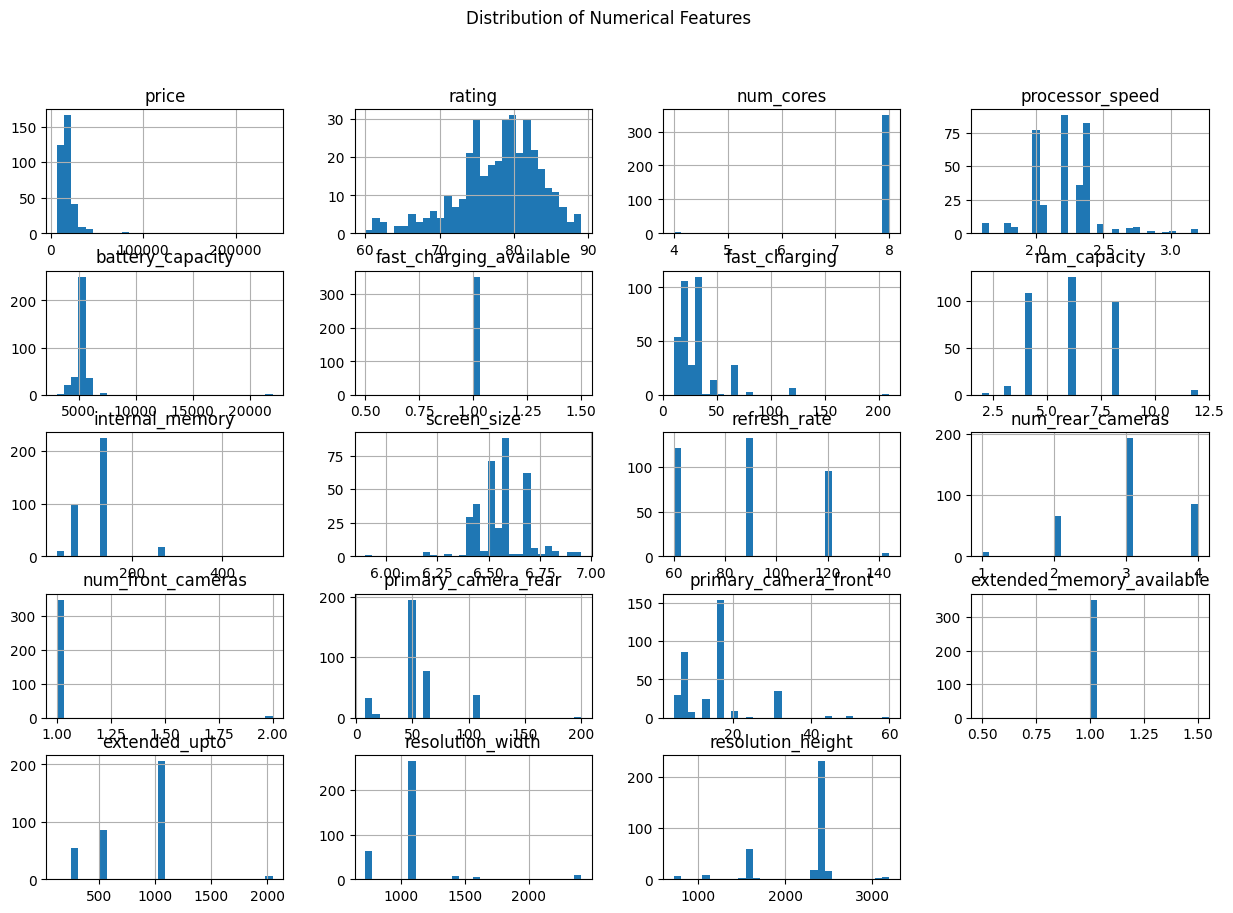

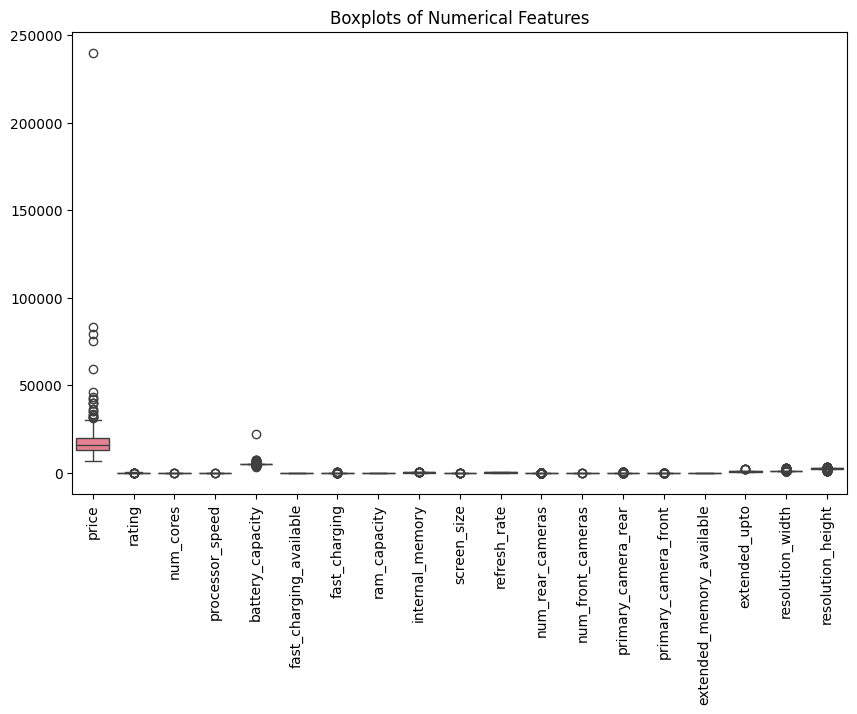

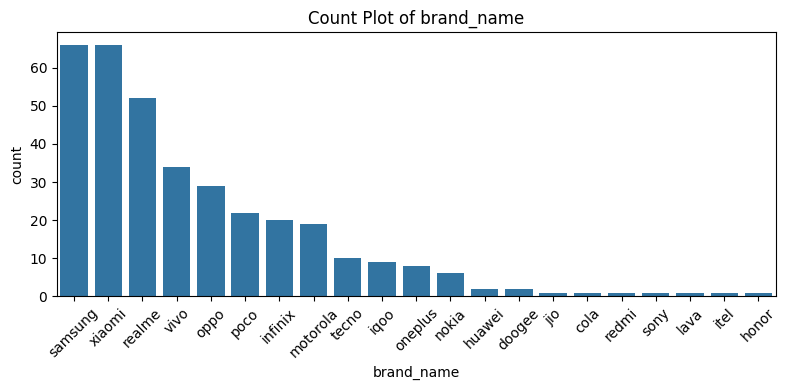

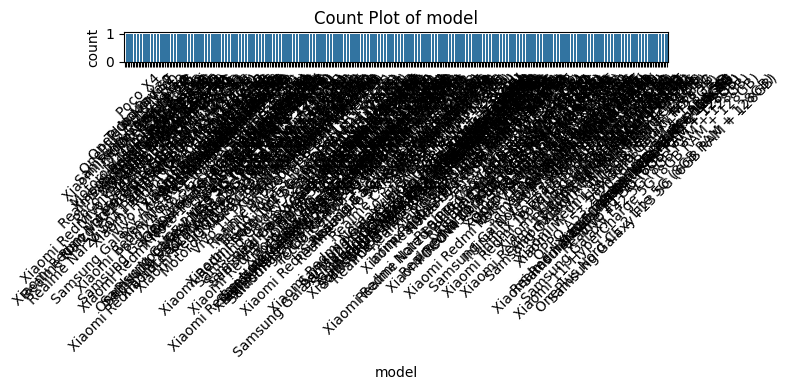

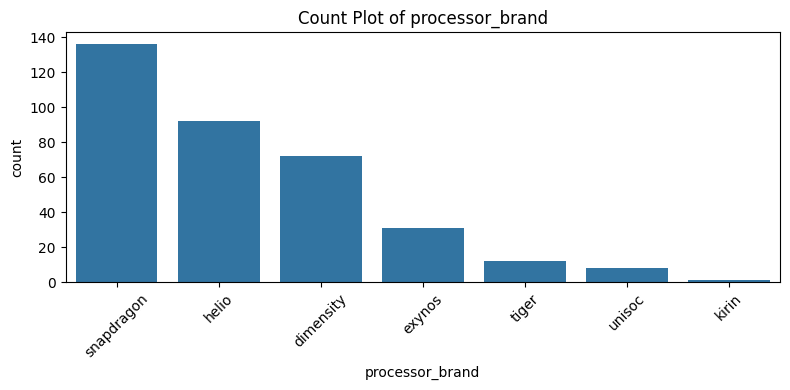

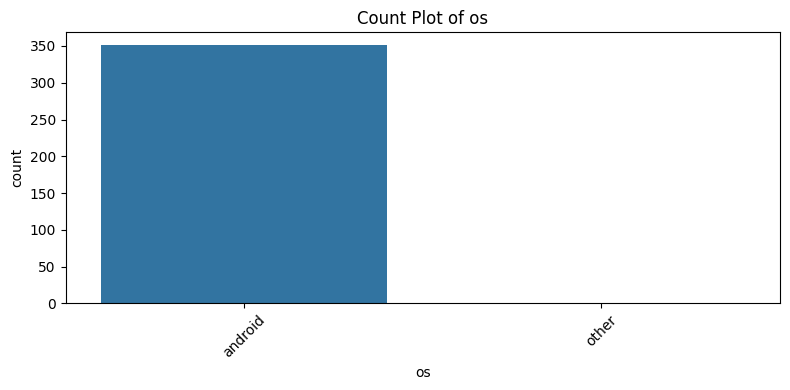

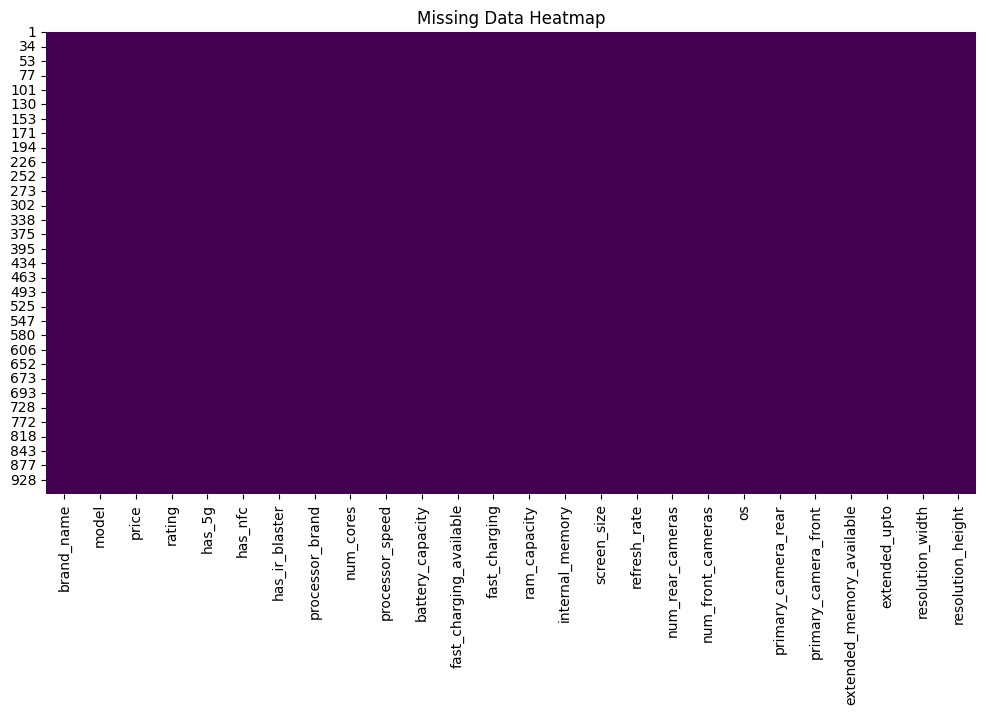


Key Insights:
1. There are multiple categorical features like Brand, Model, and OS.
2. Some columns have missing data, especially in camera and battery-related fields.
3. Numerical features such as 'Price' and 'Battery' have a wide range, some with potential outliers.


In [9]:

 # Basic info
print("\nDataset Info:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe(include='all'))

# Shape of the dataset
print(f"\nShape: {df.shape}")

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical distributions
df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of Numerical Features')
plt.show()

# Boxplot example
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.select_dtypes(include=['float64', 'int64']))
plt.xticks(rotation=90)
plt.title("Boxplots of Numerical Features")
plt.show()

# Categorical counts
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Count Plot of {col}')
    plt.tight_layout()
    plt.show()

# Missing data
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

# Key Insights
print("\nKey Insights:")
print("1. There are multiple categorical features like Brand, Model, and OS.")
print("2. Some columns have missing data, especially in camera and battery-related fields.")
print("3. Numerical features such as 'Price' and 'Battery' have a wide range, some with potential outliers.")


Section 3

In [11]:
# Handling Missing Values
df.dropna(inplace=True)  # or use imputation

# Encoding Categorical Features
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Normalization
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Train/Test Split
from sklearn.model_selection import train_test_split

X = df_encoded.drop('price', axis=1)  # Assuming Price is the target
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Section 4

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Fit Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Fit Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Calculate MSE and RMSE
lr_mse = mean_squared_error(y_test, lr_preds)
lr_rmse = np.sqrt(lr_mse)

rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)

# Output Results
print("Linear Regression RMSE:", round(lr_rmse, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))


Linear Regression RMSE: 0.31
Random Forest RMSE: 0.2


Section 5

In [21]:
import joblib

# Save the better model
joblib.dump(rf, "best_model.pkl")


['best_model.pkl']

We explored a smartphone dataset with both categorical and numerical features. 
After cleaning and preprocessing, we built Linear Regression and Random Forest models 
to predict smartphone prices. Random Forest performed better with a lower RMSE. 
We used label encoding for categories, scaling for numerical data, and split the dataset 
into train-test sets. The final model was exported as a .pkl file.
